# Individual homework project 2

Leda Gale 

You will apply statistical testing and correlation analysis to the ShopNow dataset.

For each question:

1. Run the appropriate test.
2. Report the test statistic and p-value (if applicable).
3. Interpret the result in plain English.
4. Explain what it means for the business.

In [1]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
import os

/home/leda/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
print(os.getcwd())
print(os.listdir())

/home/leda/Projects/Mayerfeld_Hw2
['marketing_campaigns.csv', 'hw_2_project (1).ipynb:Zone.Identifier', 'web_sessions.csv', '.git', 'customers.csv', '.ipynb_checkpoints', 'transactions.csv', 'hw_2_project (1).ipynb']


In [3]:
# Import datasets
customers = pd.read_csv("customers.csv")
transactions =  pd.read_csv("transactions.csv")
sessions = pd.read_csv("web_sessions.csv")
campaigns = pd.read_csv("marketing_campaigns.csv")

### Specific questions

Q1. Do customers from the UK spend more per transaction than customers from Germany?

H0 (Null Hypothesis): There is no significant difference between the mean transaction spend of UK customers and Germany custoners.

H1 (Alternative Hypothesis): There is a significant difference between the mean transaction spend of UK customers and Germany customers.

In [4]:
customers.head()

,customer_id,age,gender,country,acquisition_channel,signup_date
0,1,56.0,Other,Germany,referral,2019-07-21
1,2,38.0,Other,Netherlands,email,2022-03-04
2,3,28.0,Other,Australia,referral,2024-05-21
3,4,19.0,Female,Australia,paid_search,2022-06-28
4,5,38.0,Female,Australia,referral,2024-07-17


In [5]:
# Merging the dataset to link transactions with country information 
# Common key "customer_id"
customers_transactions = pd.merge(transactions,customers, on = "customer_id", how = "left")

---- Descriptive Statistics ---
UK Average Spend: 75.63


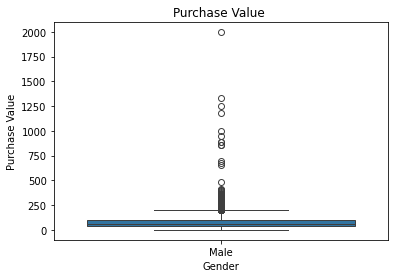

Germany Average Spend: 75.76
Difference: 0.13

---- Statistical test ---
t-statistic: -0.112
p-value: 0.91082
Conclusion: Fail to Reject the Null Hypothesis (No statistically significant difference found.)


In [7]:
# Preparing the datasets per country
uk_customers = customers_transactions[customers_transactions["country"] == "UK"]["purchase_value"]
germany_customers = customers_transactions[customers_transactions["country"] == "Germany"]["purchase_value"]

# Getting a brief descriptive statistics
print(f'---- Descriptive Statistics ---')
print(f'UK Average Spend: {uk_customers.mean():.2f}')
sns.boxplot(x="gender", y="purchase_value", data = customers_transactions[customers_transactions["gender"] == "Male"])

plt.title("Purchase Value ")
plt.xlabel("Gender")
plt.ylabel("Purchase Value")

plt.show()
print(f'Germany Average Spend: {germany_customers.mean():.2f}')
print(f"Difference: {abs(uk_customers.mean() - germany_customers.mean()):.2f}")

# Statistical test (T-test)
t_stat, p_value = ttest_ind(uk_customers, germany_customers, equal_var = False)

print(f'\n---- Statistical test ---')
print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.5f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant difference found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant difference found.)")

To determine if UK customers spend more per transaction than German customers, an independent t-test was conducted. The null Hypothesis for this case assumed there was no difference in the mean spent between the two groups. A p-value of 0.91 is greater than the significance threshold of 0.05; the test fails to reject the null hypothesis. In conclusion, it was observed that the difference in spending is not statistically significant.

NOTE: Because the number of transactions and the variance (spread) of spending might be different in both countries, the Welch’s T-test was used by setting equal_var=False.

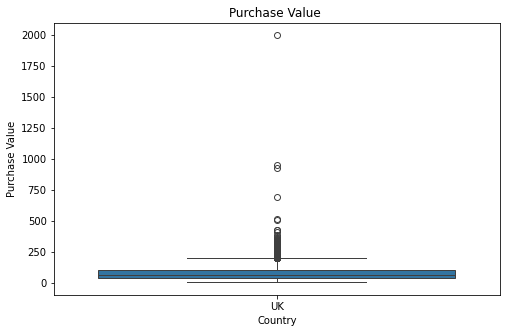

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x="country", y="purchase_value", data = customers_transactions[customers_transactions["country"] == "UK"])

plt.title("Purchase Value ")
plt.xlabel("Country")
plt.ylabel("Purchase Value")

plt.show()

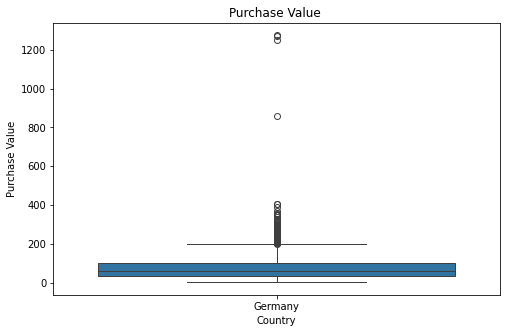

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x="country", y="purchase_value", data = customers_transactions[customers_transactions["country"] == "Germany"])

plt.title("Purchase Value ")
plt.xlabel("Country")
plt.ylabel("Purchase Value")

plt.show()

Q2. Do discounted purchases differ in average value from non-discounted purchases?

H0 (Null Hypothesis): There is no significant difference between the mean of discounted purchases and non - discounted purchases.

H1 (Alternative Hypothesis): There is significant difference between the mean of discounted purchases and non - discounted purchases.

In [10]:
transactions.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date
0,1,8141,home,74.32,0,2023-09-05
1,2,1297,fashion,17.51,0,2019-08-07
2,3,7930,toys,39.96,1,2020-02-07
3,4,2426,electronics,43.79,0,2020-10-02
4,5,6614,fashion,187.01,0,2023-09-15


In [11]:
# Preparing the datasets 
discounted_purchases = transactions[transactions["discount_used"] == 1]["purchase_value"]
nondiscounted_purchases = transactions[transactions["discount_used"] == 0]["purchase_value"]

# Getting a brief descriptive statistics
print(f'---- Descriptive Statistics ---')
print(f'Discounted Purchases: {discounted_purchases.mean():.2f}')
print(f'Non-Discounted Purchases:  {nondiscounted_purchases.mean():.2f}')
print(f"Difference: {abs(discounted_purchases.mean() - nondiscounted_purchases.mean()):.2f}")

# Statistical test (T-test)
t_stat, p_value = ttest_ind(discounted_purchases, nondiscounted_purchases, equal_var = False)

print(f'\n---- Statistical test ---')
print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.200f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant difference found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant difference found.)")

---- Descriptive Statistics ---
Discounted Purchases: 64.40
Non-Discounted Purchases:  80.76
Difference: 16.37

---- Statistical test ---
t-statistic: -29.982
p-value: 0.00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000761119
Conclusion: Reject the Null Hypothesis (Statistically Significant difference found.)


To determine if discounted purchases differ in average value from non-discounted purchases, an independent t-test was conducted. The null Hypothesis assumed there was no difference in the mean purchase value between the two transactions. The analysis showed a difference of 16.37 in the mean of both purchases The p-value in this case is significantly lower than the threshold of 0.05. The test rejects the null hypothesis, as it was observed that the difference in spending is statistically significant.

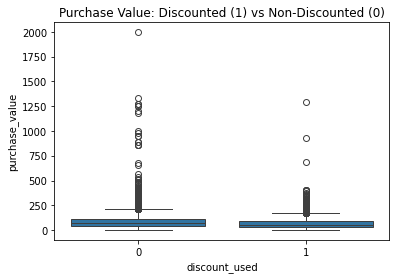

In [12]:
# Quick code to visualize the difference
sns.boxplot(x='discount_used', y='purchase_value', data=transactions)
plt.title('Purchase Value: Discounted (1) vs Non-Discounted (0)')
plt.show()

Q3. Do male and female customers differ in average purchase value?

H0 (Null Hypothesis): There is no significant difference between the mean transaction spend of male and female custoners.

H1 (Alternative Hypothesis): There is no significant difference between the mean transaction spend of male and female customers.

In [13]:
# Preparing the datasets per gender
male_customers = customers_transactions[customers_transactions["gender"] == "Male"]["purchase_value"]
female_customers = customers_transactions[customers_transactions["gender"] == "Female"]["purchase_value"]

# Getting a brief descriptive statistics
print(f'---- Descriptive Statistics ---')
print(f'Male Average Spend: {male_customers.mean():.2f}')
print(f'Female Average Spend: {female_customers.mean():.2f}')
print(f"Difference: {abs(male_customers.mean() - female_customers.mean()):.2f}")

# Statistical test (T-test)
t_stat, p_value = ttest_ind(male_customers, female_customers, equal_var = False)

print(f'\n---- Statistical test ---')
print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.5f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant difference found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant difference found.)")

---- Descriptive Statistics ---
Male Average Spend: 76.04
Female Average Spend: 75.31
Difference: 0.74

---- Statistical test ---
t-statistic: 1.083
p-value: 0.27903
Conclusion: Fail to Reject the Null Hypothesis (No statistically significant difference found.)


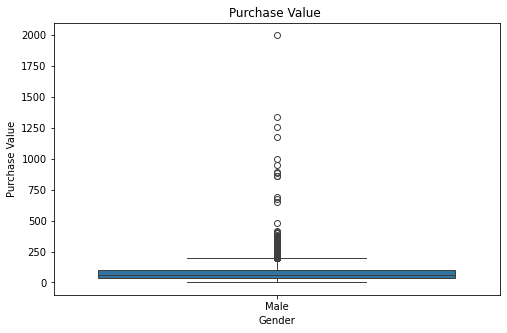

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x="gender", y="purchase_value", data = customers_transactions[customers_transactions["gender"] == "Male"])

plt.title("Purchase Value ")
plt.xlabel("Gender")
plt.ylabel("Purchase Value")

plt.show()

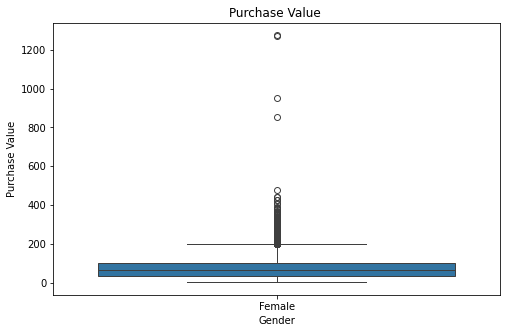

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="gender", y="purchase_value", data = customers_transactions[customers_transactions["gender"] == "Female"])

plt.title("Purchase Value ")
plt.xlabel("Gender")
plt.ylabel("Purchase Value")

plt.show()

Q4. Do customers acquired via email spend more than those from social channels?

H0 (Null Hypothesis): There is no significant difference between the mean transaction spend of customers acquired via email and the customers acquired from social media channels.

H1 (Alternative Hypothesis): There is significant difference between the mean transaction spend of customers acquired via email and the customers acquired from social media channels.

In [18]:
customers_transactions.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date,age,gender,country,acquisition_channel,signup_date
0,1,8141,home,74.32,0,2023-09-05,39.0,Male,UK,social,2021-04-13
1,2,1297,fashion,17.51,0,2019-08-07,43.0,Female,Spain,email,2024-03-10
2,3,7930,toys,39.96,1,2020-02-07,19.0,Male,Netherlands,referral,2022-11-28
3,4,2426,electronics,43.79,0,2020-10-02,67.0,Female,Australia,referral,2023-09-14
4,5,6614,fashion,187.01,0,2023-09-15,50.0,Other,Germany,paid_search,2021-10-20


In [19]:
# Preparing the datasets per acquisition_channel
email_customers = customers_transactions[customers_transactions["acquisition_channel"] == "email"]["purchase_value"]
social_customers = customers_transactions[customers_transactions["acquisition_channel"] == "social"]["purchase_value"]

# Getting a brief descriptive statistics
print(f'---- Descriptive Statistics ---')
print(f'Email customers Average Spend: {email_customers.mean():.2f}')
print(f'Social media customers  Average Spend: {social_customers.mean():.2f}')
print(f"Difference: {abs(email_customers.mean() - social_customers.mean()):.2f}")

# Statistical test (T-test)
t_stat, p_value = ttest_ind(email_customers, social_customers, equal_var = False)

print(f'\n---- Statistical test ---')
print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.5f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant difference found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant difference found.)")

---- Descriptive Statistics ---
Email customers Average Spend: 75.43
Social media customers  Average Spend: 76.04
Difference: 0.61

---- Statistical test ---
t-statistic: -0.698
p-value: 0.48546
Conclusion: Fail to Reject the Null Hypothesis (No statistically significant difference found.)


Q5. Is device type associated with conversion?

H0 (Null Hypothesis): There is no significant association between the device used and the likelihood of conversion. Device type and conversion status are independent.

H1 (Alternative Hypothesis): There is a significant association between the device used and the likelihood of a conversion. Device type and conversion status are dependent.

In [20]:
sessions.head()

,session_id,customer_id,pages_viewed,time_on_site,device_type,traffic_source,session_date,converted
0,1,9716,8,271.238207,desktop,organic,2022-06-18,0
1,2,4617,5,257.386842,mobile,social,2020-07-03,0
2,3,1506,4,289.679888,tablet,paid,2020-12-12,0
3,4,3869,5,146.543376,mobile,direct,2023-09-12,0
4,5,6245,3,339.228209,mobile,email,2019-04-02,0


In [21]:
# Preparing the dataset
device_conversion = pd.crosstab(sessions["device_type"], sessions["converted"])

# Statistical test (Chi-square test)
chi2, p_value, dof, expected = chi2_contingency(device_conversion)

print(f'\n---- Statistical test ---')
print(f'Chi-square statistic: {chi2:.3f}')
print(f'p-value: {p_value:.5f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant association has been found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant association has been found.)")


---- Statistical test ---
Chi-square statistic: 1.150
p-value: 0.56265
Conclusion: Fail to Reject the Null Hypothesis (No statistically significant association has been found.)


To determine if the device used is associated with the likelihood of conversion, a chi-square test was conducted. The null Hypothesis assumed there was no association between the two factors. The analysis showed a p-vale of 0.56, which is significantly higher than the threshold of 0.05. A low chi-square value means that the observed data is very close to the expected data. The test fails to reject the null hypothesis, concluding that there is no significant association between the device type and the likelihood of conversion. The two factors are independent.

Q6. Is acquisition channel associated with conversion?

H0 (Null Hypothesis): There is no significant association between the acquisition channel and the likelihood of conversion. Acquisition channel and conversion status are independent.

H1 (Alternative Hypothesis): There is a significant association between the acquisition channel and the likelihood of a conversion. Acquisition channel and conversion status are dependent.

In [28]:
customers_sessions = pd.merge(customers, sessions, on = "customer_id", how = "left")
customers_sessions.head()

,customer_id,age,gender,country,acquisition_channel,signup_date,session_id,pages_viewed,time_on_site,device_type,traffic_source,session_date,converted
0,1,56.0,Other,Germany,referral,2019-07-21,2120.0,1.0,196.864430,desktop,social,2019-06-24,0.0
1,1,56.0,Other,Germany,referral,2019-07-21,14328.0,5.0,324.635250,tablet,paid,2022-12-27,0.0
2,1,56.0,Other,Germany,referral,2019-07-21,18339.0,6.0,153.507768,tablet,email,2021-10-18,0.0
3,1,56.0,Other,Germany,referral,2019-07-21,19608.0,7.0,317.455502,desktop,email,2024-05-22,1.0
4,1,56.0,Other,Germany,referral,2019-07-21,27409.0,7.0,310.371599,desktop,organic,2022-03-04,0.0


In [30]:
# Preparing the dataset
channel_conversion = pd.crosstab(customers_sessions["acquisition_channel"], customers_sessions["converted"])

# Statistical test (Chi-square -test)
chi2, p_value, dof, expected = chi2_contingency(channel_conversion)

print(f'\n---- Statistical test ---')
print(f'Chi-square statistic: {chi2:.3f}')
print(f'p-value: {p_value:.5f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant association has been found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant association has been found.)")


---- Statistical test ---
Chi-square statistic: 6.775
p-value: 0.34213
Conclusion: Fail to Reject the Null Hypothesis (No statistically significant association has been found.)


To determine if the acquisition channel is associated with the likelihood of conversion, a chi-square test was conducted was conducted. The null Hypothesis assumed there was no association between the two factors. The analysis showed a p-vale of 0.34, which is significantly higher than the threshold of 0.05. The test fails to reject the null hypothesis, concluding that there is no significant association between the acquisition channel and the likelihood of conversion. The two factors are independent.

Q7. Is product category associated with discount usage?

H0 (Null Hypothesis): There is no significant association between the product category and the discount usage. Product category and the discount usage are independent.

H1 (Alternative Hypothesis): There is a significant association between the product category and the discount usage. Product category and discount usage are dependent.

In [35]:
transactions.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date
0,1,8141,home,74.32,0,2023-09-05
1,2,1297,fashion,17.51,0,2019-08-07
2,3,7930,toys,39.96,1,2020-02-07
3,4,2426,electronics,43.79,0,2020-10-02
4,5,6614,fashion,187.01,0,2023-09-15


In [36]:
# Preparing the dataset
category_discount = pd.crosstab(transactions["product_category"], transactions["discount_used"])

# Statistical test (Chi-square -test)
chi2, p_value, dof, expected = chi2_contingency(category_discount)

print(f'\n---- Statistical test ---')
print(f'Chi-square statistic: {chi2:.3f}')
print(f'p-value: {p_value:.5f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant association has been found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant association has been found.)")


---- Statistical test ---
Chi-square statistic: 1.462
p-value: 0.91739
Conclusion: Fail to Reject the Null Hypothesis (No statistically significant association has been found.)


To determine if the product category is associated with the discount usage, a chi-square test was conducted. The null Hypothesis assumed there was no association between the two factors. The analysis showed a p-vale of 0.91, which is significantly higher than the threshold of 0.05. The test fails to reject the null hypothesis, concluding that there is no significant association between the product category and the discount usage. The two factors are independent.

Q8. Is time on site correlated with purchase value?

H0 (Null Hypothesis): There is no significant correlation between the time on site and the purchase value. Time on site and the purchase value are independent.

H1 (Alternative Hypothesis): There is a significant correlation between the time on site and the purchase value. Time on site and purchase value are dependent.

In [46]:
df_merged = pd.merge(transactions, sessions, on = "customer_id", how = "left")
df_merged.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date,session_id,pages_viewed,time_on_site,device_type,traffic_source,session_date,converted
0,1,8141,home,74.32,0,2023-09-05,704.0,6.0,320.812161,mobile,organic,2019-11-23,0.0
1,1,8141,home,74.32,0,2023-09-05,9872.0,5.0,279.318762,tablet,paid,2022-06-14,0.0
2,1,8141,home,74.32,0,2023-09-05,11135.0,6.0,344.270408,desktop,paid,2021-04-25,1.0
3,1,8141,home,74.32,0,2023-09-05,23843.0,8.0,363.132454,desktop,email,2019-10-18,0.0
4,1,8141,home,74.32,0,2023-09-05,26425.0,4.0,524.913948,tablet,social,2021-05-04,0.0


In [56]:
# Preparing the dataset
df_merged = pd.merge(transactions, sessions, on = "customer_id", how = "left")
df_merged = df_merged.dropna(subset = ["purchase_value","time_on_site"])

# Statistical test (Pearon Correlation Coefficient -test)
corr = df_merged[["purchase_value","time_on_site"]].corr()
corr, p_value = pearsonr(df_merged["purchase_value"], df_merged["time_on_site"])

print(f'\n---- Statistical test ---')
print(f'Correlation statistic: {corr:.3f}')
print(f'p-value: {p_value:.5f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant association has been found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant association has been found.)")


---- Statistical test ---
Correlation statistic: -0.002
p-value: 0.34794
Conclusion: Fail to Reject the Null Hypothesis (No statistically significant association has been found.)


To determine if the time on site is correlated with the purchase value, a Pearson Correlation Coefficient test was conducted. The null Hypothesis assumed there was no correlation between the two factors. The analysis showed a p-vale of 0.35, which is significantly higher than the threshold of 0.05. The test fails to reject the null hypothesis, concluding that there is no significant correlation between the time on site and the purchase value. The two factors are independent.

Q9. Is the number of pages viewed correlated with purchase value?

H0 (Null Hypothesis): There is no significant correlation between the number of pages viewed and the purchase value. The number of pages viewed and the purchase value are independent.

H1 (Alternative Hypothesis): There is a significant correlation between the number of pages viewed and the purchase value. The number of pages viewed and purchase value are dependent.

In [58]:
# Preparing the dataset
#df_merged = pd.merge(transactions, sessions, on = "customer_id", how = "left")
df_merged = df_merged.dropna(subset = ["purchase_value","pages_viewed"])

# Statistical test (Pearon Correlation Coefficient -test)
corr = df_merged[["purchase_value","pages_viewed"]].corr()
corr, p_value = pearsonr(df_merged["purchase_value"], df_merged["pages_viewed"])

print(f'\n---- Statistical test ---')
print(f'Correlation statistic: {corr:.8f}')
print(f'p-value: {p_value:.5f}')

# Interpretation 
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant association has been found.)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No statistically significant association has been found.)")


---- Statistical test ---
Correlation statistic: 0.00009204
p-value: 0.95879
Conclusion: Fail to Reject the Null Hypothesis (No statistically significant association has been found.)


To determine if the pages viewed are correlated with the purchase value, a Pearson Correlation Coefficient test was conducted. The null Hypothesis assumed there was no correlation between the two factors. The analysis showed a p-vale of 0.95, which is significantly higher than the threshold of 0.05. The test fails to reject the null hypothesis, concluding that there is no significant correlation between the pages viewed and the purchase value. The two factors are independent.

Q10. Is time on site correlated with pages viewed?

### Challenges

C1. Explore whether high-spending customers behave differently in terms of session time.

Define “high spending” yourself.

C2. Find a relationship (difference or correlation) that you believe is meaningful for business strategy.

Explain why.

c3. Identify a statistically significant result that may not be practically meaningful.

Explain why statistical significance ≠ business importance.